In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)

## Data Collection & Understanding

In [20]:
df = pd.read_csv('/content/breast-cancer-wisconsin-data (1).csv')

## Data Preprocessing & Cleaning

In [21]:
df_clean = df.drop(columns=['id'])
le = LabelEncoder()
df_clean['diagnosis'] = le.fit_transform(df_clean['diagnosis']) # M=1, B=0

## Exploratory Data Analysis (EDA)

### 1. Class Distribution

/tmp/ipykernel_706/2864223902.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diagnosis', data=df_clean, palette='Set2')


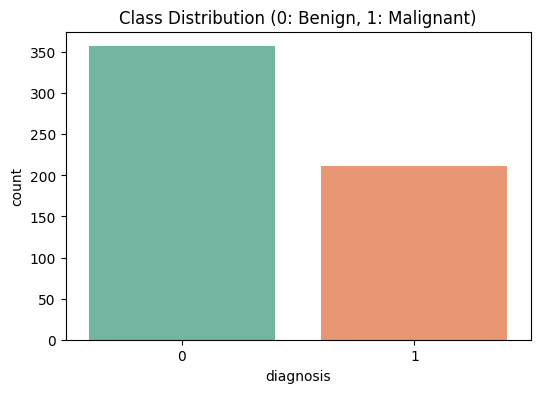

In [22]:
plt.figure(figsize=(6, 4))
sns.countplot(x='diagnosis', data=df_clean, palette='Set2')
plt.title('Class Distribution (0: Benign, 1: Malignant)')
plt.savefig('eda_distribution.png')

### 2. Correlation Heatmap

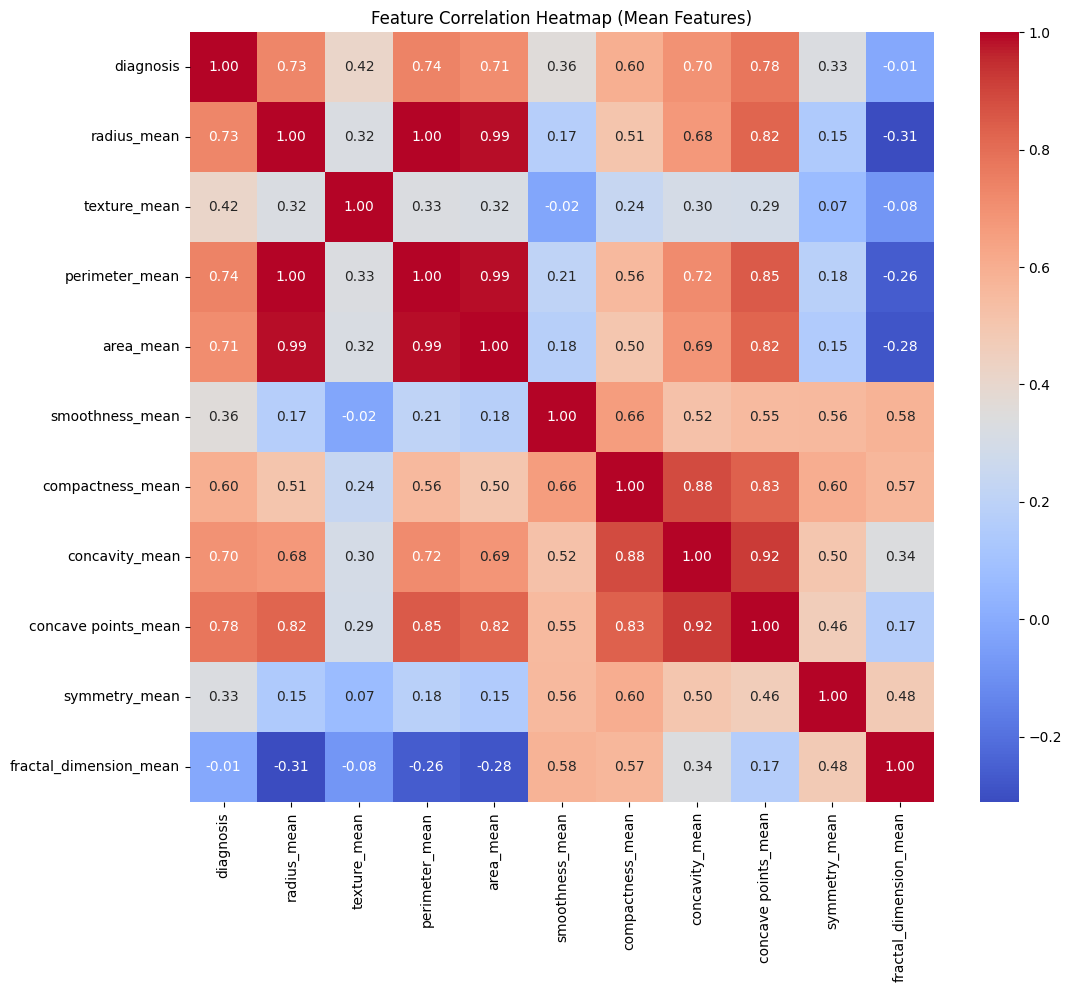

In [23]:
plt.figure(figsize=(12, 10))
sns.heatmap(df_clean.iloc[:, :11].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap (Mean Features)')
plt.savefig('eda_correlation.png')

Feature Engineering & Selection

In [24]:
X = df_clean.drop(columns=['diagnosis'])
y = df_clean['diagnosis']

Split data

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Feature Scaling

In [26]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Dimensionality Reduction using PCA

In [27]:
from sklearn.decomposition import PCA

# Apply PCA
pca = PCA(n_components=10)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original Shape:", X_train_scaled.shape)
print("PCA Shape:", X_train_pca.shape)

Original Shape: (455, 30)
PCA Shape: (455, 10)


Explained Variance Graph

Explained Variance Ratio:
[0.44593522 0.18545255 0.09584641 0.06593768 0.05622286 0.03988488
 0.02214493 0.01614006 0.01284789 0.01165661]
Total Variance Retained: 0.9520691014391005


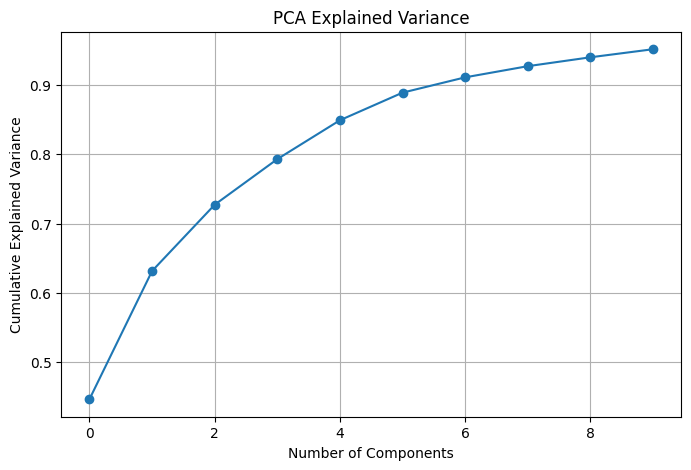

In [28]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,5))

plt.plot(np.cumsum(pca.explained_variance_ratio_),
         marker='o')

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("Total Variance Retained:",
      np.sum(pca.explained_variance_ratio_))

plt.grid(True)
plt.show()

Train Logistic Regression Using PCA Data

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

pca_model = LogisticRegression()

pca_model.fit(X_train_pca, y_train)

y_pred_pca = pca_model.predict(X_test_pca)

print("PCA Model Accuracy:",
      accuracy_score(y_test, y_pred_pca))

PCA Model Accuracy: 0.9736842105263158


Model Building & Training

In [30]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'SVM': SVC(probability=True, kernel='linear', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model

Model Evaluation & Comparison

In [31]:
results = []
for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'CV Mean': cv_scores.mean()
    })

comparison_df = pd.DataFrame(results)
print("\n--- STAGE 7: MODEL COMPARISON TABLE ---")
print(comparison_df.to_string(index=False))


--- STAGE 7: MODEL COMPARISON TABLE ---
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC  CV Mean
Logistic Regression  0.964912      0.975 0.928571  0.951220 0.996032 0.971429
                SVM  0.964912      1.000 0.904762  0.950000 0.991402 0.962637
      Random Forest  0.973684      1.000 0.928571  0.962963 0.992890 0.962637


Model Interpretation & Explainability

In [32]:
best_model_name = comparison_df.sort_values(by='Accuracy', ascending=False).iloc[0]['Model']
print(f"\n>> The mathematically best model is: {best_model_name}")


>> The mathematically best model is: Random Forest


1. Confusion Matrix for the best model

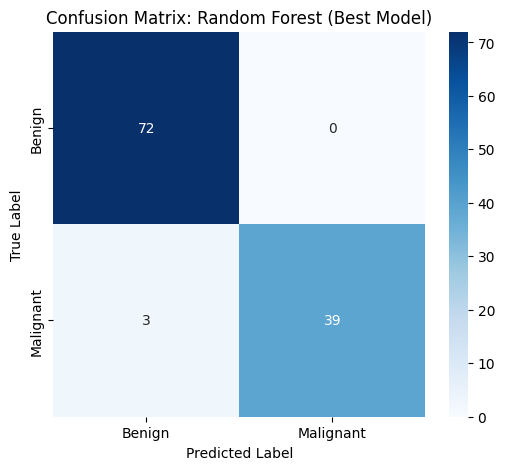

In [33]:
y_pred_best = trained_models[best_model_name].predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix: {best_model_name} (Best Model)')
plt.show()

Feature Importance

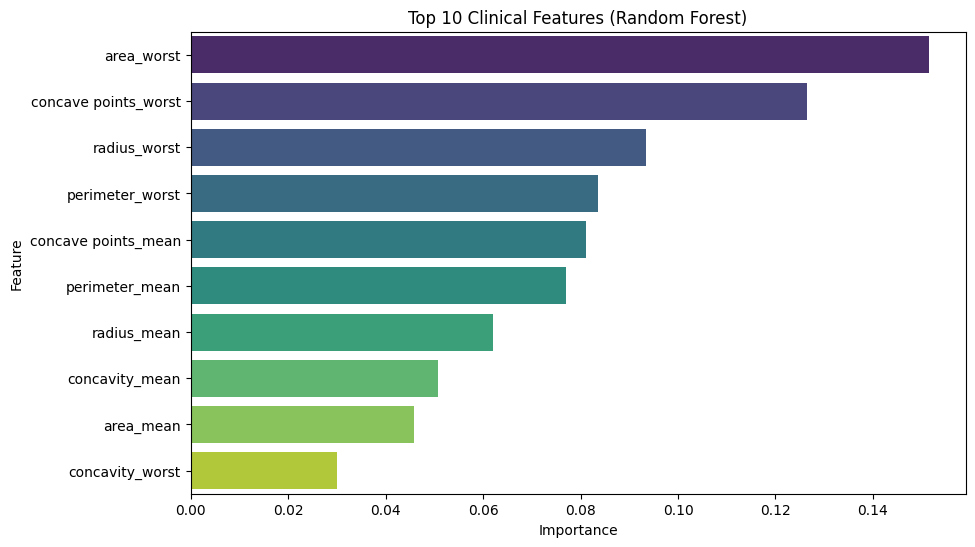


--- STAGE 8: TOP 5 PREDICTIVE FEATURES ---


In [34]:
rf_model = trained_models['Random Forest']
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
# Fixed: added hue and legend=False to prevent warning
sns.barplot(x='Importance', y='Feature', data=feat_imp.head(10), hue='Feature', palette='viridis', legend=False)
plt.title('Top 10 Clinical Features (Random Forest)')
plt.show()

print("\n--- STAGE 8: TOP 5 PREDICTIVE FEATURES ---")
